# Combined Dataset Visualization
This notebook processes and visualizes multiple FLUMY datasets for comparison.

In [1]:
import os
import random
import numpy as np
import pyvista as pv
from pathlib import Path
import sys
from pathlib import Path
scripts_dir = Path.cwd().parents[1]
if str(scripts_dir) not in sys.path:
    sys.path.insert(0, str(scripts_dir))
from gan_pipeline.core import custom_plots as custom_plots
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from scipy.stats import entropy
from matplotlib.colors import ListedColormap, BoundaryNorm
from ipywidgets import interact, IntSlider, Dropdown, Layout, Checkbox, VBox, HBox

In [2]:
facies_properties = {
    'undefined':           {'val': 0,  'color': "#ff0000", 'grain_size': 0,  'porosity_class': 0,    'description': "Background/Undefined"},
    'channel_lag':         {'val': 1,  'color': "#f1970f", 'grain_size': 13, 'porosity_class': -2,   'description': "Active channel fill, coarse-grained"},
    'point_bar':           {'val': 2,  'color': "#f3dd12", 'grain_size': 10, 'porosity_class': 1,    'description': "Lower energy channel margins"},
    'sand_plug':           {'val': 3,  'color': "#af8f00", 'grain_size': 9,  'porosity_class': 2,    'description': "Fine-grained oxbow/plug fill"},
    'crevasse_splay_core': {'val': 4,  'color': "#fffc65", 'grain_size': 9,  'porosity_class': 2,    'description': "Proximal high-energy splay"},
    'crevasse_channel':    {'val': 5,  'color': "#ffd986", 'grain_size': 8,  'porosity_class': 3,    'description': "Feeder channel for splays"},
    'crevasse_splay_delta':{'val': 6,  'color': "#ff9853", 'grain_size': 7,  'porosity_class': 2,    'description': "Distal fan-like splay deposit"},
    'levee':               {'val': 7,  'color': "#27ae60", 'grain_size': 6,  'porosity_class': 5,    'description': "Sand/silt ridges bordering channel"},
    'overbank':            {'val': 8,  'color': "#33ff00", 'grain_size': 3,  'porosity_class': 8,    'description': "Stabilized/vegetated levee"},
    'mud_plug':            {'val': 9,  'color': "#fff7db", 'grain_size': 2,  'porosity_class': 10.5, 'description': "Fine silts/clays far from channel"},
    'hemipelagic_plug':    {'val': 10, 'color': "#7a7d80", 'grain_size': 2,  'porosity_class': 10.5, 'description': "Silts near active channel belts"},
    'wetland':             {'val': 11, 'color': "#d862f0", 'grain_size': 1,  'porosity_class': 12.5, 'description': "Organic rich, very fine sediment"},
    'draping':             {'val': 12, 'color': "#8dd5e7", 'grain_size': 1,  'porosity_class': 12.5, 'description': "Lateral accretion sand bodies"},
    'pelagic':             {'val': 13, 'color': "#3498db", 'grain_size': 1,  'porosity_class': 12.5, 'description': "Lacustrine clay/silt"}
}

val_to_info = {
    info['val']: {
        'color': info['color'], 
        'name': key.replace('_', ' ').title()
    } 
    for key, info in facies_properties.items()
}

save_plots=True

In [3]:
base_dir = Path(r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM")
output_dir = Path(r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\preprocessing_plots")
training_dir = base_dir / "datasets" / "training"

dataset_paths = [d for d in training_dir.iterdir() if d.is_dir()]
dataset_names = [d.name for d in dataset_paths]

print(f"Found {len(dataset_names)} datasets:")
for i, name in enumerate(dataset_names):
    os.makedirs(os.path.join(output_dir,name),exist_ok=True)
    print(f"{i+1}. {name}")

Found 3 datasets:
1. setting_1_nexus_1000_samples_ntg_67_chdepth_6_isbx_100
2. setting_2_nexus_1000_samples_ntg_67_chdepth_5_isbx_80
3. setting_3_nexus_1000_samples_ntg_67_chdepth_7_isbx_120


## Facies Distribution Comparison

In [4]:
def get_dataset_distribution(dataset_path):
    facies_dir = dataset_path / "samples" / "facies"
    files = list(facies_dir.glob("*.npy"))
    total_counts = np.zeros(14, dtype=np.int64)
    
    print(f"Processing {dataset_path.name} ({len(files)} samples)...")
    for f in files:
        grid = np.load(f)
        counts = np.bincount(grid.ravel(), minlength=14)
        total_counts += counts
        
    total_voxels = total_counts.sum()
    percentages = (total_counts / total_voxels) * 100
    print(percentages)
    return percentages

all_distributions = []
for path in dataset_paths:
    all_distributions.append(get_dataset_distribution(path))

Processing setting_1_nexus_1000_samples_ntg_67_chdepth_6_isbx_100 (1000 samples)...
[0.00000000e+00 1.75996742e+00 6.62688324e+01 1.55480976e+00
 4.14638519e-03 8.88568878e-02 9.90753174e-03 6.51098557e+00
 1.13652718e+01 1.24372223e+01 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00]
Processing setting_2_nexus_1000_samples_ntg_67_chdepth_5_isbx_80 (1000 samples)...
[0.00000000e+00 1.60880585e+00 6.75212994e+01 1.76103573e+00
 4.04701233e-03 1.00698662e-01 1.05190277e-02 5.21022873e+00
 1.02171066e+01 1.35662590e+01 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00]
Processing setting_3_nexus_1000_samples_ntg_67_chdepth_7_isbx_120 (1000 samples)...
[0.00000000e+00 1.90500145e+00 6.54219398e+01 1.44688454e+00
 4.36782837e-03 8.03220749e-02 8.67404938e-03 7.68897171e+00
 1.19265045e+01 1.15173340e+01 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00]


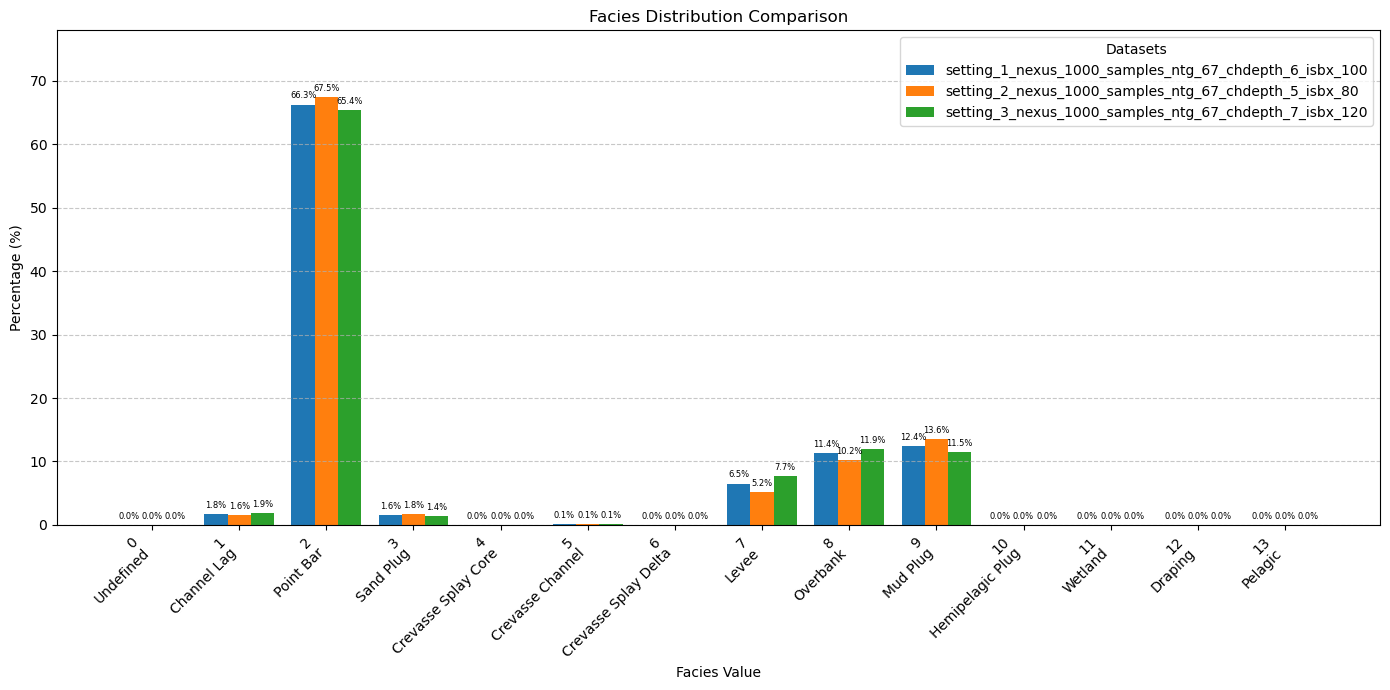

In [5]:
def plot_combined_distribution(distributions, dataset_names):
    title = 'Facies Distribution Comparison'
    num_datasets = len(distributions)
    x = np.arange(14)
    width = 0.8 / num_datasets
    
    fig, ax = plt.subplots(figsize=(14, 7))
    
    for i, dist in enumerate(distributions):
        # 1. Capture the bar container into a variable (rects)
        rects = ax.bar(x + i*width - (num_datasets-1)*width/2, dist, width, label=dataset_names[i])
        
        # 2. Add the labels above the bars
        # 'fmt' handles the rounding. '%.1f%%' gives 1 decimal place (e.g., 12.3%). 
        # Use '%.0f%%' if you want whole numbers (e.g., 12%).
        ax.bar_label(rects, padding=3, fmt='%.1f%%', fontsize=6, rotation=0)
    
    ax.set_xlabel('Facies Value')
    ax.set_ylabel('Percentage (%)')
    ax.set_title(f'{title}')
    ax.set_xticks(x)
    ax.set_xticklabels([f"{v}\n{val_to_info[v]['name']}" for v in x], rotation=45, ha='right')
    ax.legend(title="Datasets")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Optional: Give the top of the chart a bit of breathing room so labels don't get cut off
    ax.set_ylim(top=ax.get_ylim()[1] * 1.1)
    
    plt.tight_layout()

    if save_plots:
        plt.savefig(os.path.join(output_dir, title), dpi=400)
    plt.show()

plot_combined_distribution(all_distributions, dataset_names) 

## 2D plus distribution

## Spatial Entropy Analysis
Entropy maps visualize the spatial variability across the realization ensemble. High entropy (warmer colors) indicates areas of geological uncertainty or high variability between realizations.

Saved entropy plot to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\preprocessing_plots\setting_1_nexus_1000_samples_ntg_67_chdepth_6_isbx_100\Spatial_Entropy_setting_1_nexus_1000_samples_ntg_67_chdepth_6_isbx_100.png


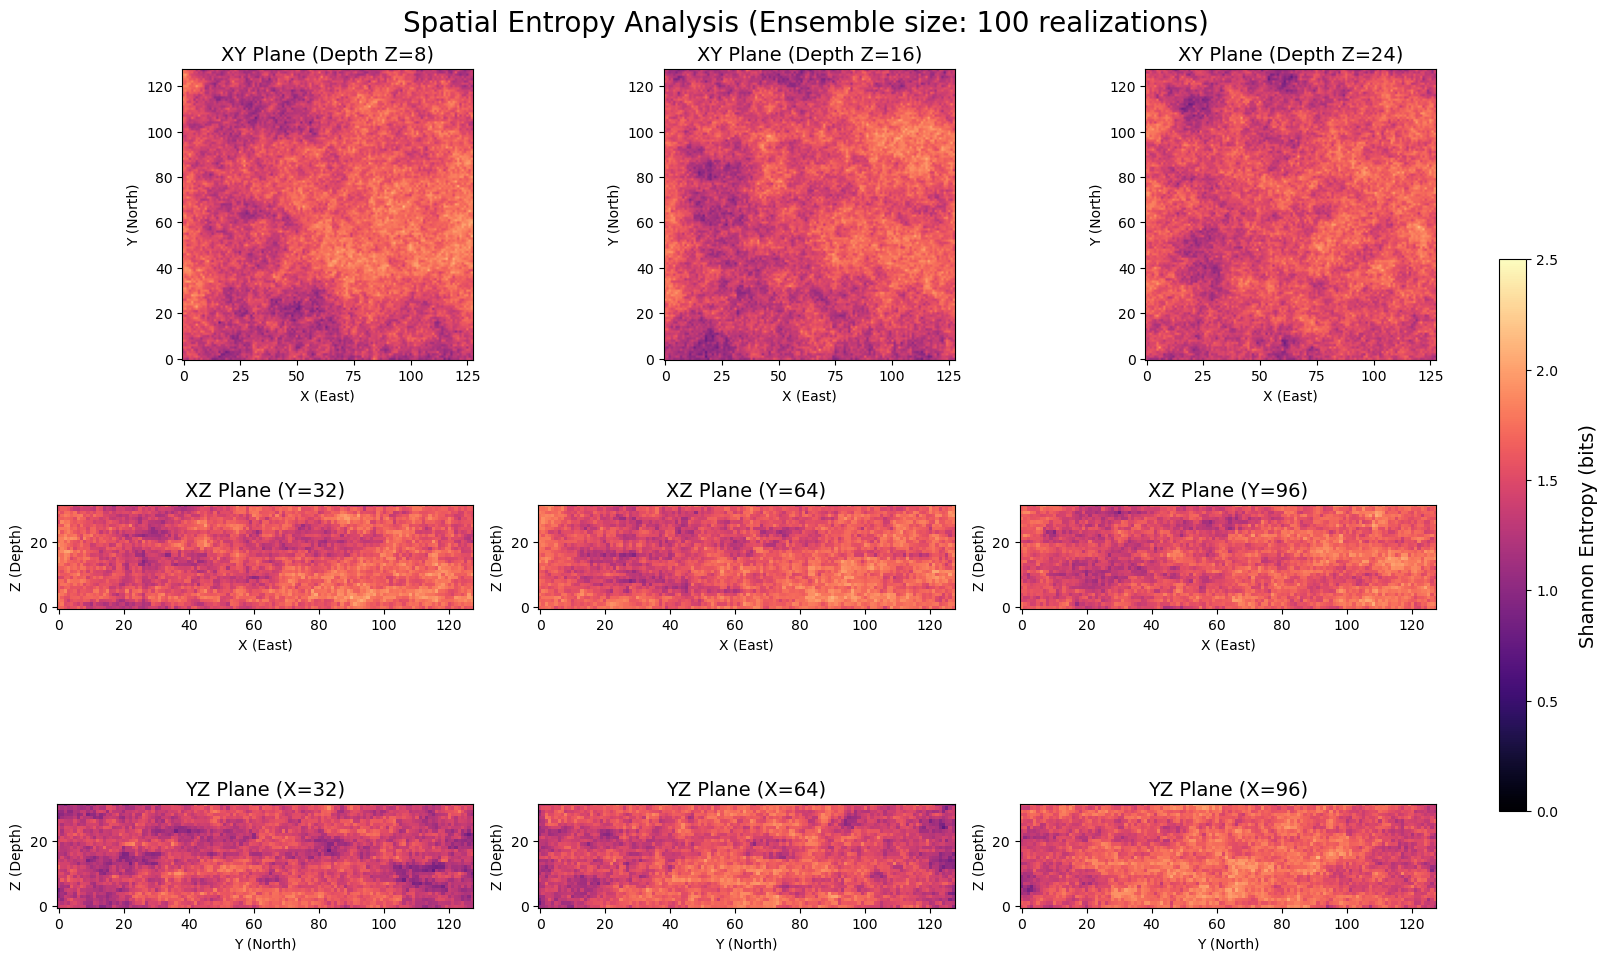

Saved entropy plot to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\preprocessing_plots\setting_2_nexus_1000_samples_ntg_67_chdepth_5_isbx_80\Spatial_Entropy_setting_2_nexus_1000_samples_ntg_67_chdepth_5_isbx_80.png


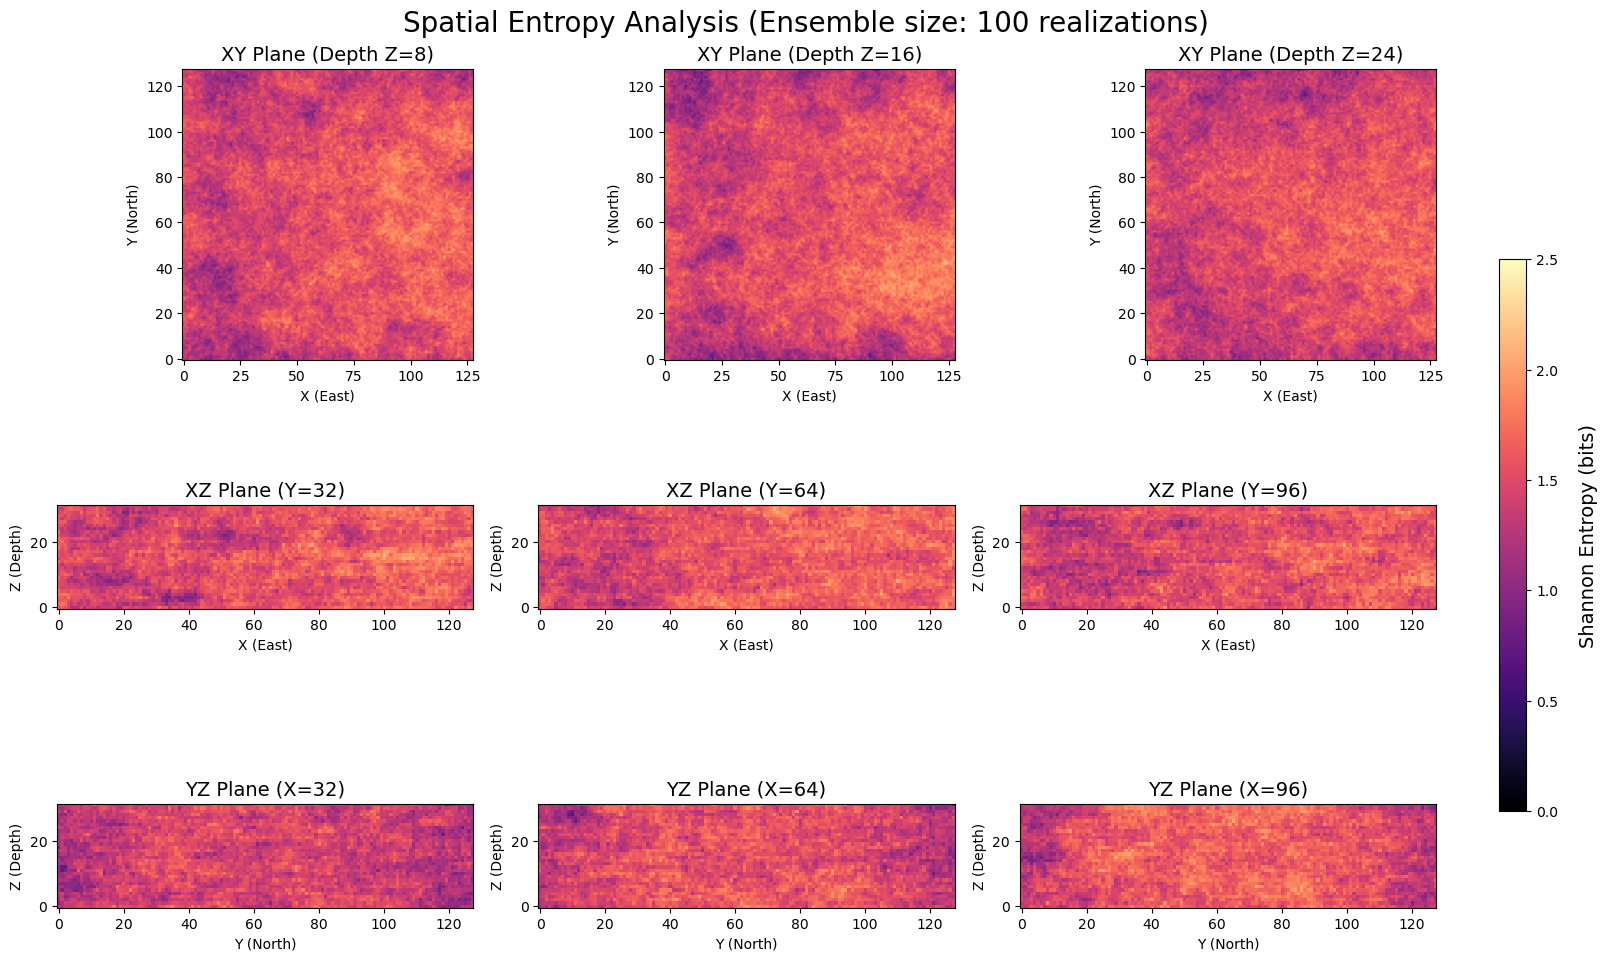

Saved entropy plot to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\preprocessing_plots\setting_3_nexus_1000_samples_ntg_67_chdepth_7_isbx_120\Spatial_Entropy_setting_3_nexus_1000_samples_ntg_67_chdepth_7_isbx_120.png


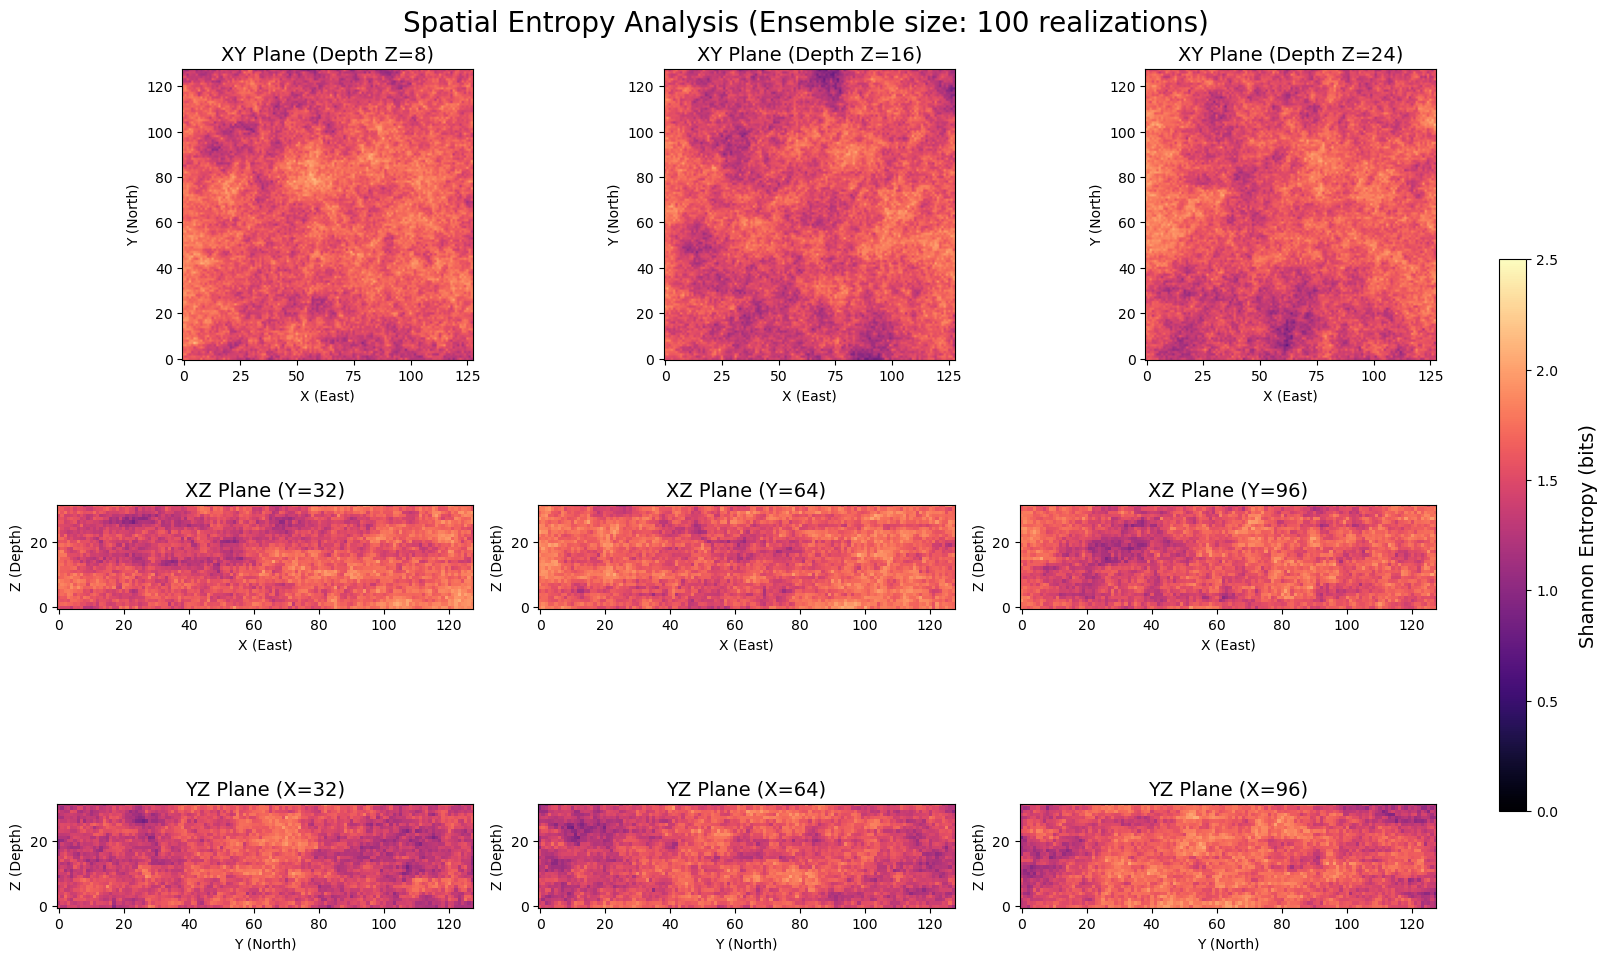

In [6]:
def plot_dataset_spatial_entropy(dataset_path, dataset_name, max_samples=100):
    """
    Calculates and plots cell-wise entropy across realizations.
    Displays a 3x3 grid: 
    - Row 1: 3 XY slices (Z-axis)
    - Row 2: 3 XZ slices (Y-axis)
    - Row 3: 3 YZ slices (X-axis)
    """
    facies_dir = dataset_path / "samples" / "facies"
    files = list(facies_dir.glob("*.npy"))
    if not files:
        print(f"No samples found for {dataset_name}")
        return
    
    # Use a statistically significant subset for calculation
    num_to_use = min(len(files), max_samples)
    subset_files = sorted(random.sample(files, num_to_use))
    
    # Load dimensions
    ref = np.load(subset_files[0])
    nz, ny, nx = ref.shape
    
    # Representative indices (Quarter, Half, Three-Quarter)
    z_idx = [nz//4, nz//2, 3*nz//4]
    y_idx = [ny//4, ny//2, 3*ny//4]
    x_idx = [nx//4, nx//2, 3*nx//4]
    
    # Collect data for selected slices only to manage memory
    stack_z = np.zeros((num_to_use, 3, ny, nx), dtype=np.uint8)
    stack_y = np.zeros((num_to_use, 3, nz, nx), dtype=np.uint8)
    stack_x = np.zeros((num_to_use, 3, nz, ny), dtype=np.uint8)
    
    for i, f in enumerate(subset_files):
        vol = np.load(f)
        stack_z[i] = vol[z_idx, :, :]
        stack_y[i] = vol[:, y_idx, :].transpose(1, 0, 2)
        stack_x[i] = vol[:, :, x_idx].transpose(2, 0, 1)

    def get_entropy_map(slice_stack):
        # Probabilities for each of the 14 facies
        probs = np.zeros((14, slice_stack.shape[1], slice_stack.shape[2]))
        for v in range(14):
            probs[v] = np.sum(slice_stack == v, axis=0) / num_to_use
        return entropy(probs, base=2, axis=0)

    fig, axes = plt.subplots(3, 3, figsize=(16, 10), constrained_layout=True)
    fig.suptitle(f"Spatial Entropy Analysis (Ensemble size: {num_to_use} realizations)",fontsize=20)

    # Max entropy for 14 classes is ~3.8, but 2.5 is a practical limit for visualization
    vmax = 2.5

    # 1. Z-Slices (XY Plane)
    for j in range(3):
        ent_map = get_entropy_map(stack_z[:, j, :, :])
        im = axes[0, j].imshow(ent_map, cmap='magma', origin='lower', vmin=0, vmax=vmax)
        axes[0, j].set_title(f"XY Plane (Depth Z={z_idx[j]})", fontsize=14)
        axes[0, j].set_xlabel("X (East)")
        axes[0, j].set_ylabel("Y (North)")

    # 2. Y-Slices (XZ Plane)
    for j in range(3):
        ent_map = get_entropy_map(stack_y[:, j, :, :])
        im = axes[1, j].imshow(ent_map, cmap='magma', origin='lower', aspect='equal', vmin=0, vmax=vmax)
        axes[1, j].set_title(f"XZ Plane (Y={y_idx[j]})", fontsize=14)
        axes[1, j].set_xlabel("X (East)")
        axes[1, j].set_ylabel("Z (Depth)")

    # 3. X-Slices (YZ Plane)
    for j in range(3):
        ent_map = get_entropy_map(stack_x[:, j, :, :])
        im = axes[2, j].imshow(ent_map, cmap='magma', origin='lower', aspect='equal', vmin=0, vmax=vmax)
        axes[2, j].set_title(f"YZ Plane (X={x_idx[j]})", fontsize=14)
        axes[2, j].set_xlabel("Y (North)")
        axes[2, j].set_ylabel("Z (Depth)")

    # Colorbar
    cbar = fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)
    cbar.set_label('Shannon Entropy (bits)', fontsize=14, labelpad=15)
    
    if save_plots:
        output_plot_path = os.path.join(output_dir, dataset_path.name,f"Spatial_Entropy_{dataset_name}.png")
        plt.savefig(output_plot_path, dpi=300, bbox_inches='tight')
        print(f"Saved entropy plot to: {output_plot_path}")
    plt.show()

# Run for all datasets
for path, name in zip(dataset_paths, dataset_names):
    plot_dataset_spatial_entropy(path, name)

## Grouped Spatial Entropy Analysis (3 Classes)
This analysis groups the 14 facies into the 3 main architectural categories used during GAN training: 
1. **Group 0 (Channel):** Channel Lag, Point Bar, Sand Plug.
2. **Group 1 (Crevasse/Levee):** Crevasse Splay, Crevasse Channel, Levee.
3. **Group 2 (Floodplain):** Overbank, Mud Plug, Hemipelagic, Wetland, Draping, Pelagic.

This visualization helps evaluate the "geological uncertainty" specifically between the high-level sedimentological groups.

Saved combined entropy plot to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\preprocessing_plots\Spatial_Entropy_Grouped_Combined.png


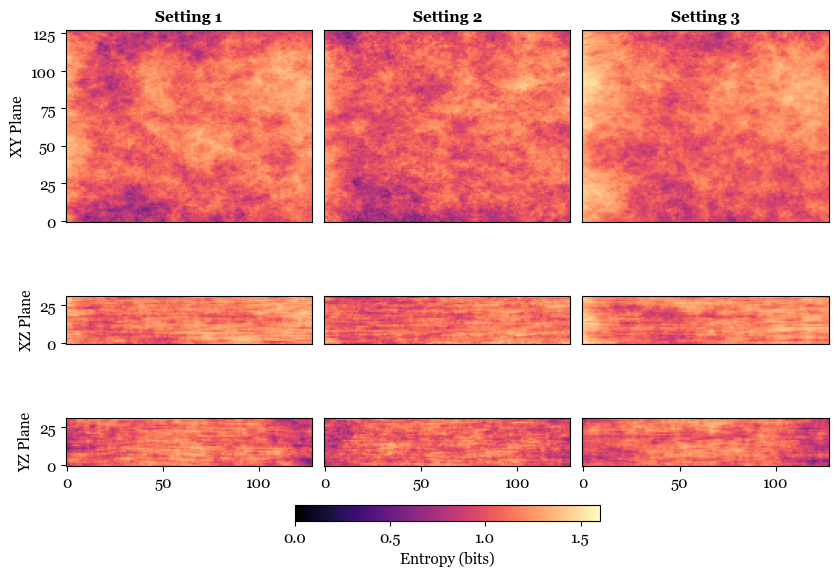

In [14]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy.stats import entropy
from pathlib import Path

def plot_combined_grouped_spatial_entropy(dataset_paths, dataset_names, output_dir, max_samples=100, save_plots=True):
    # 1. Set font settings (Georgia, ~11pt)
    rcParams['font.family'] = 'serif'
    rcParams['font.serif'] = ['Georgia']
    rcParams['font.size'] = 11

    # 2. Get reference shape from the first available dataset
    ref_file = next((dataset_paths[0] / "samples" / "facies").glob("*.npy"))
    nz, ny, nx = np.load(ref_file).shape
    
    # 3. Calculate figure dimensions 
    a4_width = 8.27
    num_datasets = len(dataset_paths)
    
    # To make the top plot square, its height must equal its width (a4_width / num_datasets).
    # We calculate the total required height of the axes area, then add ~1.5 inches for colorbar/titles.
    axes_height = (a4_width / num_datasets) * ((nx + 2 * nz) / nx)
    fig_height = axes_height + 1.5 
    
    # Use 'nx' for the top row's height ratio to force it into a square proportion.
    # Increased 'hspace' to 0.35 to widen the distances and prevent label overlap.
    fig, axes = plt.subplots(nrows=3, ncols=num_datasets, 
                             figsize=(a4_width, fig_height), 
                             gridspec_kw={'height_ratios': [nx, nz, nz], 'hspace': 0.35},
                             layout='constrained')
    
    if num_datasets == 1:
        axes = axes[:, np.newaxis]
        
    vmax = 1.6 
    im = None  

    for col, (dataset_path, dataset_name) in enumerate(zip(dataset_paths, dataset_names)):
        facies_dir = dataset_path / "samples" / "facies"
        files = list(facies_dir.glob("*.npy"))
        
        if not files: 
            continue
        
        num_to_use = min(len(files), max_samples)
        subset_files = sorted(random.sample(files, num_to_use))
        
        mapping = np.zeros(14, dtype=np.int64)
        mapping[1:4] = 0   
        mapping[4:8] = 1   
        mapping[8:14] = 2  
        
        z_idx, y_idx, x_idx = nz//2, ny//2, nx//2
        
        stack_z = np.zeros((num_to_use, ny, nx), dtype=np.uint8)
        stack_y = np.zeros((num_to_use, nz, nx), dtype=np.uint8)
        stack_x = np.zeros((num_to_use, nz, ny), dtype=np.uint8)
        
        for i, f in enumerate(subset_files):
            vol = mapping[np.load(f)]
            stack_z[i] = vol[z_idx, :, :]
            stack_y[i] = vol[:, y_idx, :]
            stack_x[i] = vol[:, :, x_idx]

        def get_entropy_map(slice_stack):
            probs = np.zeros((3, slice_stack.shape[1], slice_stack.shape[2]))
            for v in range(3):
                probs[v] = np.sum(slice_stack == v, axis=0) / num_to_use
            return entropy(probs, base=2, axis=0)

        ent_xy = get_entropy_map(stack_z)
        ent_xz = get_entropy_map(stack_y)
        ent_yz = get_entropy_map(stack_x)
        
        # --- PLOTTING ---
        
        # Top Row: XY Plane (Now forced to be square via height_ratios)
        im = axes[0, col].imshow(ent_xy, cmap='magma', origin='lower', aspect='auto', vmin=0, vmax=vmax)
        axes[0, col].set_title(f"Setting {col + 1}", fontweight='bold', fontsize=11)
        axes[0, col].set_xticks([]) 
        
        # Middle Row: XZ Plane
        axes[1, col].imshow(ent_xz, cmap='magma', origin='lower', aspect='auto', vmin=0, vmax=vmax)
        axes[1, col].set_xticks([]) 
        
        # Bottom Row: YZ Plane
        axes[2, col].imshow(ent_yz, cmap='magma', origin='lower', aspect='auto', vmin=0, vmax=vmax)
        
        if col == 0:
            # Removed the plane numbers to shorten the string and prevent overlapping
            axes[0, col].set_ylabel("XY Plane")
            axes[1, col].set_ylabel("XZ Plane")
            axes[2, col].set_ylabel("YZ Plane")
        else:
            axes[0, col].set_yticks([])
            axes[1, col].set_yticks([])
            axes[2, col].set_yticks([])

    # 4. Add a single colorbar at the bottom spanning all columns
    if im is not None:
        cbar = fig.colorbar(im, ax=axes, orientation='horizontal', 
                            location='bottom', shrink=0.4, pad=0.03)
        cbar.set_label('Entropy (bits)')

    if save_plots:
        output_plot_path = os.path.join(output_dir, "Spatial_Entropy_Grouped_Combined.png")
        plt.savefig(output_plot_path, dpi=600, bbox_inches='tight')
        print(f"Saved combined entropy plot to: {output_plot_path}")
        
    plt.show()

plot_combined_grouped_spatial_entropy(dataset_paths, dataset_names, output_dir)

## 2D Side-by-Side Visualization

Saved combined facies plot to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\preprocessing_plots\Facies_Grouped_Combined.png


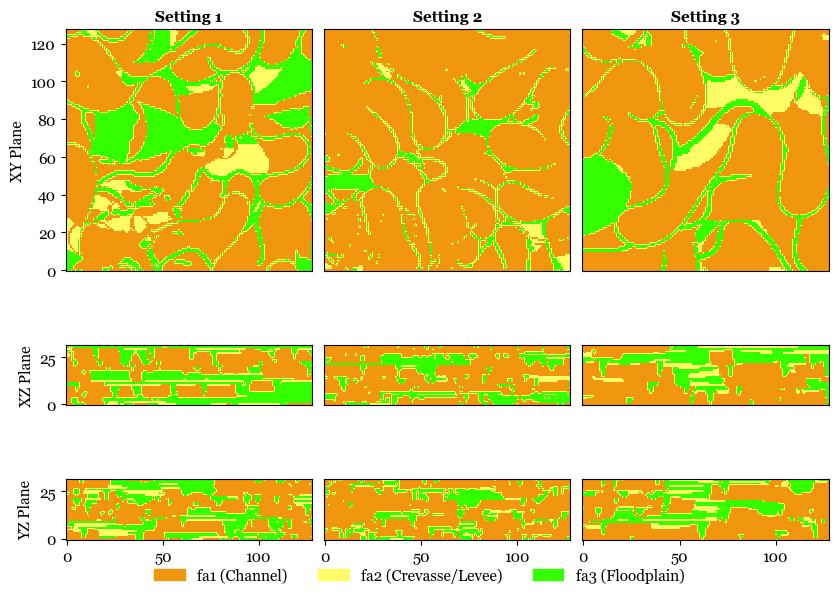

In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
from pathlib import Path

def plot_combined_grouped_facies(dataset_paths, dataset_names, output_dir, save_plots=True):
    # 1. Set font settings (Georgia, ~11pt)
    rcParams['font.family'] = 'serif'
    rcParams['font.serif'] = ['Georgia']
    rcParams['font.size'] = 11

    # 2. Get reference shape from the first available dataset
    ref_file = next((dataset_paths[0] / "samples" / "facies").glob("*.npy"))
    nz, ny, nx = np.load(ref_file).shape
    
    # 3. Calculate figure dimensions 
    a4_width = 8.27
    num_datasets = len(dataset_paths)
    
    # To make the top plot square, its height must equal its width (a4_width / num_datasets).
    axes_height = (a4_width / num_datasets) * ((nx + 2 * nz) / nx)
    fig_height = axes_height + 1.5 
    
    # Use 'nx' for the top row's height ratio to force it into a square proportion.
    fig, axes = plt.subplots(nrows=3, ncols=num_datasets, 
                             figsize=(a4_width, fig_height), 
                             gridspec_kw={'height_ratios': [nx, nz, nz], 'hspace': 0.35},
                             layout='constrained')
    
    if num_datasets == 1:
        axes = axes[:, np.newaxis]
        
    # Apply the requested custom hex colors for fa1, fa2, and fa3
    group_colors = ['#f1970f', '#fffc65', '#33ff00'] 
    cmap = ListedColormap(group_colors)
    norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], 3)

    for col, (dataset_path, dataset_name) in enumerate(zip(dataset_paths, dataset_names)):
        facies_dir = dataset_path / "samples" / "facies"
        
        # Grab only the first sample
        files = sorted(list(facies_dir.glob("*.npy")))
        if not files: 
            print(f"Skipping {dataset_name}: No .npy files found.")
            continue
        
        vol_raw = np.load(files[0])
        
        # --- ORIGINAL 3-CLASS MAPPING ---
        # Sized to 14 to safely accommodate 0-13 indices
        mapping = np.zeros(14, dtype=np.int64)
        mapping[1:4] = 0   # fa1
        mapping[4:8] = 1   # fa2
        mapping[8:14] = 2  # fa3
        
        vol = mapping[vol_raw]
        
        # Extract middle slices
        z_idx, y_idx, x_idx = nz//2, ny//2, nx//2
        slc_xy = vol[z_idx, :, :]
        slc_xz = vol[:, y_idx, :]
        slc_yz = vol[:, :, x_idx]
        
        # --- PLOTTING ---
        
        # Top Row: XY Plane 
        axes[0, col].imshow(slc_xy, cmap=cmap, norm=norm, origin='lower', aspect='auto')
        axes[0, col].set_title(f"Setting {col + 1}", fontweight='bold', fontsize=11)
        axes[0, col].set_xticks([]) 
        
        # Middle Row: XZ Plane
        axes[1, col].imshow(slc_xz, cmap=cmap, norm=norm, origin='lower', aspect='auto')
        axes[1, col].set_xticks([]) 
        
        # Bottom Row: YZ Plane
        axes[2, col].imshow(slc_yz, cmap=cmap, norm=norm, origin='lower', aspect='auto')
        
        if col == 0:
            axes[0, col].set_ylabel("XY Plane")
            axes[1, col].set_ylabel("XZ Plane")
            axes[2, col].set_ylabel("YZ Plane")
        else:
            axes[0, col].set_yticks([])
            axes[1, col].set_yticks([])
            axes[2, col].set_yticks([])

    # 4. Add a single legend at the bottom spanning all columns
    labels = ["fa1 (Channel)", "fa2 (Crevasse/Levee)", "fa3 (Floodplain)"]
    patches = [mpatches.Patch(color=group_colors[i], label=labels[i]) for i in range(3)]
    
    # Place legend underneath the plots
    fig.legend(handles=patches, loc='lower center', ncol=3, 
               bbox_to_anchor=(0.5, -0.05), frameon=False)

    if save_plots:
        output_plot_path = os.path.join(output_dir, "Facies_Grouped_Combined.png")
        plt.savefig(output_plot_path, dpi=600, bbox_inches='tight')
        print(f"Saved combined facies plot to: {output_plot_path}")
        
    plt.show()
plot_combined_grouped_facies(dataset_paths, dataset_names, output_dir)

In [ ]:
def load_sample(dataset_path, sample_name="sample_1.npy"):
    file_path = dataset_path / "samples" / "facies" / sample_name
    if file_path.exists():
        return np.load(file_path)
    return None

def create_side_by_side_viewer(dataset_paths, dataset_names):
    # Load sample 1 for each dataset
    volumes = []
    for p in dataset_paths:
        vol = load_sample(p)
        if vol is not None:
            volumes.append(vol)
    
    if not volumes:
        print("No samples found.")
        return
        
    nz, ny, nx = volumes[0].shape
    
    # Use a fixed colormap for all facies (0-13)
    colors = [val_to_info[v]['color'] for v in range(14)]
    cmap = ListedColormap(colors)
    norm = BoundaryNorm(np.arange(15) - 0.5, 14)

    def update_plot(axis, index):
        fig, axes = plt.subplots(1, len(volumes), figsize=(6 * len(volumes), 5), squeeze=False)
        
        for i, (vol, name) in enumerate(zip(volumes, dataset_names)):
            if axis == 'Z (Map View)':
                slc = vol[index, :, :]
                ylabel, xlabel = "y (North)", "x (East)"
            elif axis == 'Y (XS East-West)':
                slc = vol[:, index, :]
                ylabel, xlabel = "z (Depth)", "x (East)"
            else: # X
                slc = vol[:, :, index]
                ylabel, xlabel = "z (Depth)", "y (North)"

            im = axes[0, i].imshow(slc, origin='lower', cmap=cmap, norm=norm, aspect='auto')
            axes[0, i].set_title(f"{name}\n{axis} at {index}")
            axes[0, i].set_ylabel(ylabel)
            axes[0, i].set_xlabel(xlabel)
            
        # Single legend for all subplots
        unique_vals = np.unique([np.unique(v) for v in volumes])
        legend_elements = [mpatches.Patch(facecolor=val_to_info[v]['color'], label=f"({v}) {val_to_info[v]['name']}") 
                           for v in unique_vals if v in val_to_info]
        
        fig.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5), title="Facies")
        plt.tight_layout()
        plt.show()

    axis_dropdown = Dropdown(options=['Z (Map View)', 'Y (XS East-West)', 'X (XS North-South)'], value='Z (Map View)', description='Axis:')
    index_slider = IntSlider(min=0, max=nz-1, step=1, value=nz//2, description='Slice:', layout=Layout(width='50%'))

    def on_axis_change(change):
        if change['new'] == 'Z (Map View)':
            index_slider.max = nz - 1
        elif change['new'] == 'Y (XS East-West)':
            index_slider.max = ny - 1
        else:
            index_slider.max = nx - 1
        index_slider.value = index_slider.max // 2

    axis_dropdown.observe(on_axis_change, names='value')
    interact(update_plot, axis=axis_dropdown, index=index_slider)

create_side_by_side_viewer(dataset_paths, dataset_names)

interactive(children=(Dropdown(description='Axis:', options=('Z (Map View)', 'Y (XS East-West)', 'X (XS North-…

## 3D PyVista Visualization

In [ ]:
def plot_3d_facies(samples, sample_settings, facies_properties, custom_plots, show_legend=True, max_facies_to_plot=None):
    """
    Generates a single 3D PyVista plot of all facies from a random sample,
    and displays it with a clean Matplotlib categorical legend.
    
    Parameters:
    -----------
    samples : list
        List of file paths to the .npy sample files.
    facies_properties : dict
        Dictionary containing configuration values, colors, and names of facies.
    custom_plots : module/object
        The custom plotting module containing FaciesColorMap.
    show_legend : bool, default True
        If True, renders the Matplotlib categorical legend on the right.
    max_facies_to_plot : int, optional
        If set, restricts the rendering to only include the first 'N' unique 
        facies found in the volume (useful for decluttering complex volumes).
    """
    print("\n--- Phase 4: Generating Configurable 3D Plot ---")

    try:
        import pyvista as pv
    except ImportError:
        print("Error: 'pyvista' is not installed. Cannot run 3D plotting.")
        return None

    # 1. Select a random sample and load data
    if not samples:
        raise FileNotFoundError("No .npy files found in the 'samples' list.")
        
    random_file = random.choice(samples)
    data_3d = np.load(random_file)
    nz, ny, nx = data_3d.shape
    
    # Identify unique facies present in this specific block
    present_facies = np.unique(data_3d).astype(int)
    
    # Dynamic Filtering: Restrict number of facies plotted if requested
    if max_facies_to_plot is not None and max_facies_to_plot < len(present_facies):
        print(f"Limiting display from {len(present_facies)} facies down to {max_facies_to_plot}.")
        present_facies = present_facies[:max_facies_to_plot]
        
        # Mask out data points that aren't in our restricted list (set to background/0 or NaN)
        mask = np.isin(data_3d, present_facies)
        render_data = np.where(mask, data_3d, 0) # Fallback to 0 if excluded
    else:
        render_data = data_3d

    # 2. Setup the PyVista Grid
    grid = pv.ImageData()
    grid.dimensions = (nx + 1, ny + 1, nz + 1)
    grid.cell_data['Facies'] = render_data.transpose(2, 1, 0).flatten(order='F')

    custom_cmap = custom_plots.FaciesColorMap()

    # 3. Render 3D Scene off-screen
    plotter = pv.Plotter(off_screen=True, window_size=(1200, 1200))
    plotter.background_color = 'white'
    
    plotter.add_mesh(
        grid, 
        scalars='Facies',
        cmap=custom_cmap, 
        clim=[0, 13], 
        show_edges=False, 
        show_scalar_bar=False, # Handled via Matplotlib instead
        ambient=0.3,
        diffuse=0.7
    )
    plotter.view_isometric()
    
    # Capture image array directly from memory
    three_d_image = plotter.screenshot(None)
    plotter.close()

    # 4. Create Matplotlib Canvas for Final Layout Strategy
    # Dynamically change layout configuration based on whether legend is enabled
    if show_legend:
        fig = plt.figure(figsize=(14, 10))
        gs = gridspec.GridSpec(1, 2, width_ratios=[1.8, 0.6], wspace=0.05)
        ax_plot = fig.add_subplot(gs[0, 0])
        ax_leg  = fig.add_subplot(gs[0, 1])
        fig.suptitle(f"Complete 3D Facies Model", fontsize=20, y=0.95, fontweight='bold')
    else:
        fig = plt.figure(figsize=(10, 16))
        ax_plot = fig.add_subplot(1, 1, 1)

    # Display PyVista matrix inside Matplotlib frame
    ax_plot.set_title(f"Sample settings: {sample_settings[0]}% net to gross and {sample_settings[1]} isbx", fontsize=16)
    ax_plot.imshow(three_d_image)
    ax_plot.axis('off')

    # 5. Build Clean Categorical Legend conditionally
    if show_legend:
        ax_leg.axis('off') 
        legend_elements = []
        
        for f_name, f_props in facies_properties.items():
            if f_props['val'] in present_facies:
                patch = mpatches.Patch(
                    color=f_props['color'], 
                    label=f"{f_props['val']} - {f_name.replace('_', ' ').title()}"
                )
                legend_elements.append(patch)

        ax_leg.legend(
            handles=legend_elements, 
            loc='center left', 
            title="Legend of Facies",
            title_fontsize=13,
            fontsize=11,
            frameon=False, 
            labelspacing=1.4
        )

    # 6. Save Combined Plot
    if save_plots:
        sample_name = os.path.splitext(os.path.basename(random_file))[0]
        output_plot_path = output_dir / f"3D_plot_{sample_name}_final.png"
        plt.savefig(output_plot_path, dpi=300, bbox_inches='tight')
        print(f"Successfully saved plot execution matrix to: {output_plot_path}")
    
    plt.show()
    return


--- Phase 4: Generating Configurable 3D Plot ---
Successfully saved plot execution matrix to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\preprocessing_plots\3D_plot_sample_10453_final.png


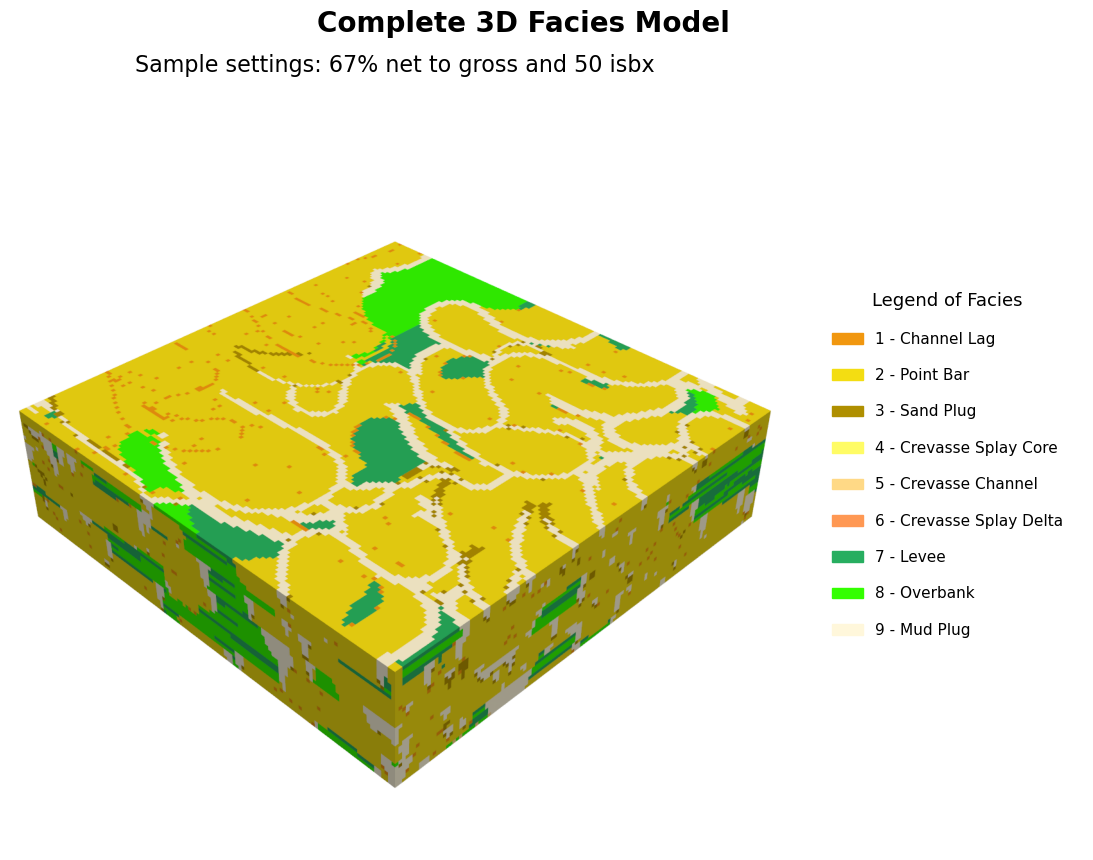


--- Phase 4: Generating Configurable 3D Plot ---
Successfully saved plot execution matrix to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\preprocessing_plots\3D_plot_sample_999_final.png


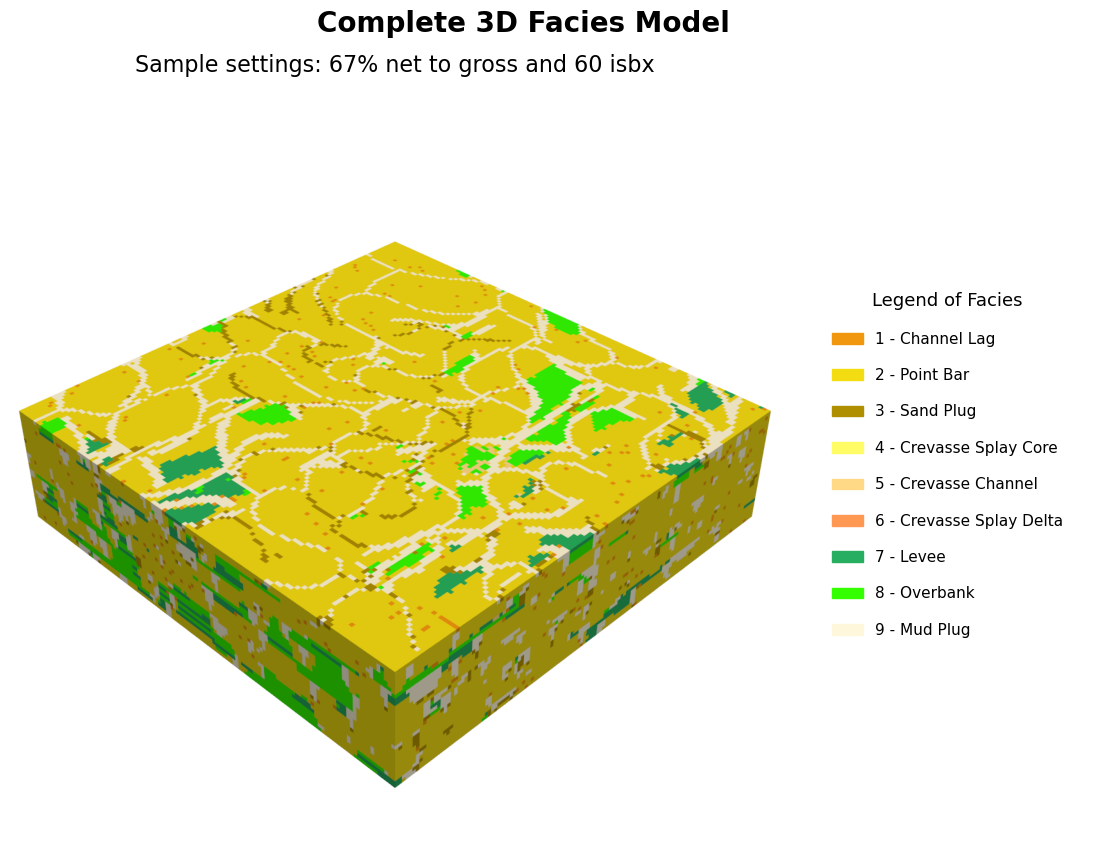


--- Phase 4: Generating Configurable 3D Plot ---
Successfully saved plot execution matrix to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\preprocessing_plots\3D_plot_sample_840_final.png


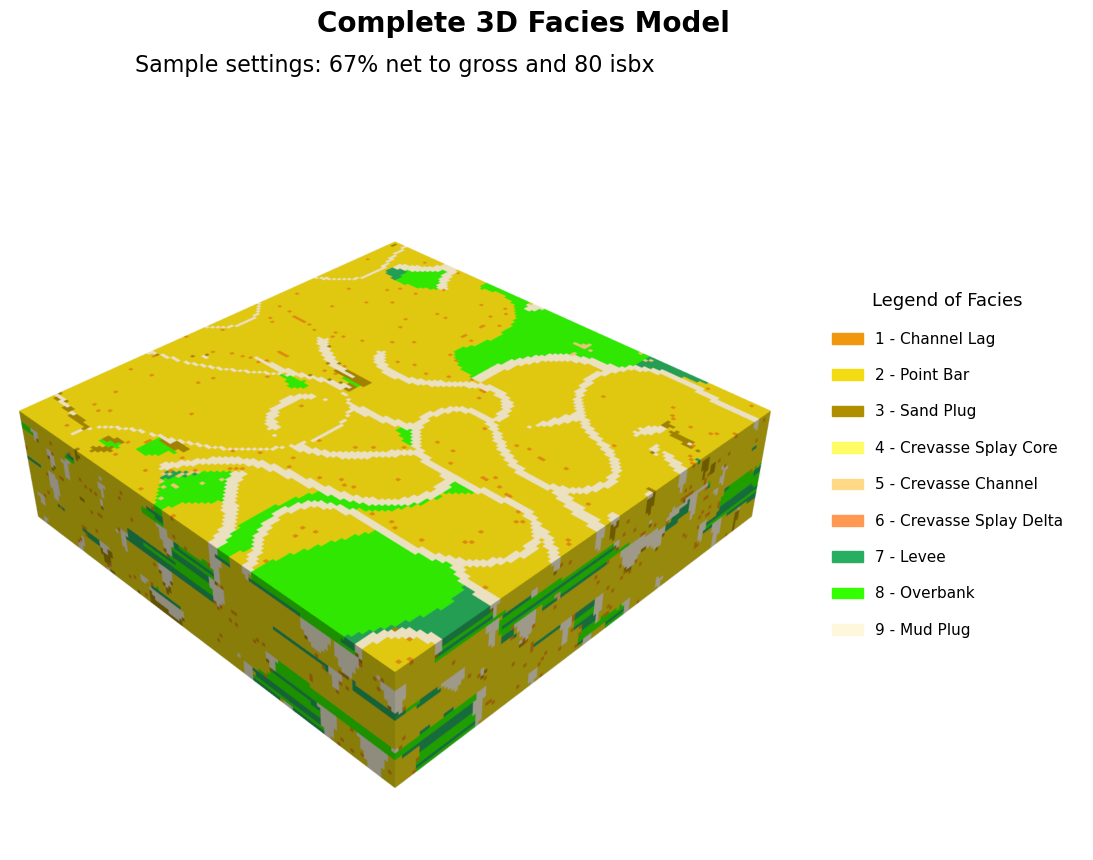

In [ ]:
dataset_params = {'setting_1': [67,50], 'setting_2': [67,60], 'setting_3': [67,80], 'setting_4':[67,100]}

# Zip pairs the first path with the first key, the second path with the second key, etc.
for dataset_path, param_key in zip(dataset_paths, dataset_params.keys()):
    samples = list((dataset_path / "samples" / "facies").glob("*.npy"))
    
    if samples:
        # Extract the specific parameter value for this iteration (e.g., {67, 100})
        current_param = dataset_params[param_key]
        
        # Pass the specific param (or just the key, depending on what your function expects)
        plot_3d_facies(samples, current_param, facies_properties, custom_plots, show_legend=True, max_facies_to_plot=10)
    else:
        print(f"No .npy sample files found in {dataset_path}. Skipping 3D plot generation.")

In [ ]:
# # ==============================================================================
# # FINAL REPORT CUSTOM PLOT (GridSpec 4x6)
# # ==============================================================================
# import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec
# from scipy.stats import entropy
# import pyvista as pv
# import random
# import glob
# import os
# import numpy as np
# import matplotlib.colors as mcolors
# from sklearn.manifold import MDS
# from skimage.util import view_as_windows
# from collections import Counter

# # --- 1. Compute MPS Frequencies & run MDS ---
# n_mds_samples = 20  # Limit samples to avoid excessive computation time
# all_counters = []

# for i, p in enumerate(dataset_paths):
#     files = glob.glob(os.path.join(p, '*.npy'))[:n_mds_samples]
#     for file in files:
#         grid = np.load(file)
#         # 3x3x3 windows flattened to 27 elements
#         windows = view_as_windows(grid, (3, 3, 3)).reshape(-1, 27)
#         # Take a random sample of 2000 windows per grid to speed up
#         idx = np.random.choice(windows.shape[0], 2000, replace=False)
#         windows_sampled = windows[idx]
#         c = Counter(tuple(w) for w in windows_sampled)
#         all_counters.append(c)

# # Find top K most common patterns globally to use as features
# global_counter = Counter()
# for c in all_counters:
#     global_counter.update(c)
# top_patterns = [pat for pat, count in global_counter.most_common(100)]

# # Build feature matrix X
# X_mps = np.zeros((len(all_counters), len(top_patterns)))
# for idx, c in enumerate(all_counters):
#     for j, pat in enumerate(top_patterns):
#         X_mps[idx, j] = c.get(pat, 0)

# mds = MDS(n_components=2, random_state=42, normalized_stress='auto')
# mds_results = mds.fit_transform(X_mps)

# # --- Layout Setup ---
# fig = plt.figure(figsize=(20, 14))
# gs = gridspec.GridSpec(4, 6, figure=fig)
# gs.update(hspace=0.5, wspace=0.5)

# ax_mds = fig.add_subplot(gs[0:3, 0:2])
# ax_3d = fig.add_subplot(gs[0:3, 2:4])
# ax_entropy = fig.add_subplot(gs[0:3, 4:6])

# ax_facies1 = fig.add_subplot(gs[3, 0:2])
# ax_facies2 = fig.add_subplot(gs[3, 2:4])
# ax_facies3 = fig.add_subplot(gs[3, 4:6])

# # --- 2. Plot MDS ---
# colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
# samples_per_dataset = n_mds_samples
# for i, name in enumerate(dataset_names):
#     start_idx = i * samples_per_dataset
#     end_idx = (i + 1) * samples_per_dataset
#     ax_mds.scatter(mds_results[start_idx:end_idx, 0], mds_results[start_idx:end_idx, 1], \
#                    label=name, alpha=0.7, color=colors[i], edgecolors='w', s=50)

# ax_mds.set_title('2D MDS of Datasets (MPS Frequencies)', fontsize=14)
# ax_mds.set_xlabel('MDS Dimension 1', fontsize=12)
# ax_mds.set_ylabel('MDS Dimension 2', fontsize=12)
# ax_mds.legend(title='Datasets')
# ax_mds.grid(True, linestyle='--', alpha=0.6)

# # --- Helper for 3D Pyvista Plots ---
# def render_pyvista_to_ax(ax, grid, cmap, title="3D Render"):
#     pv.global_theme.background = 'white'
#     plotter = pv.Plotter(off_screen=True)
#     grid_pv = pv.ImageData()
#     grid_pv.dimensions = np.array(grid.shape) + 1
#     grid_pv.spacing = (1, 1, 1)
#     grid_pv.cell_data["Values"] = grid.flatten(order="F")
#     plotter.add_mesh(grid_pv, scalars="Values", cmap=cmap, show_edges=False, show_scalar_bar=False)
#     plotter.camera_position = 'iso'
#     img = plotter.screenshot(transparent_background=False)
#     ax.imshow(img)
#     ax.axis('off')
#     ax.set_title(title, fontsize=14)

# # --- 3. 3D pyvista plot of random sample ---
# all_files = []
# for p in dataset_paths:
#     all_files.extend(glob.glob(os.path.join(p, '*.npy')))

# random_file = random.choice(all_files)
# grid_data = np.load(random_file)

# # Use an appealing categorical colormap for facies
# cmap_facies = mcolors.ListedColormap(['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'])
# render_pyvista_to_ax(ax_3d, grid_data, cmap=cmap_facies, title="3D Render (Random Sample)")

# # --- 4. Pyvista entropy plot of the setting ensemble ---
# # Reading 300 random samples to avoid MemoryError while getting a good ensemble estimation
# subset_files = random.sample(all_files, min(len(all_files), 300))
# ensemble_grids = []
# for file in subset_files:
#     ensemble_grids.append(np.load(file))
# ensemble_grids = np.stack(ensemble_grids)

# unique_facies = np.unique(ensemble_grids)
# entropy_grid = np.zeros(ensemble_grids.shape[1:])
# for facies in unique_facies:
#     prob = np.mean(ensemble_grids == facies, axis=0)
#     prob_safe = np.where(prob > 0, prob, 1)
#     entropy_grid -= prob * np.log2(prob_safe)

# render_pyvista_to_ax(ax_entropy, entropy_grid, cmap='magma', title="3D Pixel-wise Entropy (Ensemble)")

# # --- 5. Facies proportions plots ---
# facies_axes = [ax_facies1, ax_facies2, ax_facies3]
# x_facies = np.arange(14)
# for i, ax in enumerate(facies_axes):
#     dist = all_distributions[i]
#     ax.bar(x_facies, dist, color=colors[i], alpha=0.8)
#     ax.set_title(f'Facies Proportion: {dataset_names[i]}', fontsize=12)
#     ax.set_xlabel('Facies Value')
#     ax.set_ylabel('Percentage (%)')
#     ax.set_xticks(x_facies)
#     ax.set_xticklabels([f"{v}\\n{val_to_info[v]['name']}" if v in val_to_info else str(v) for v in x_facies], rotation=45, ha='right')
#     ax.grid(axis='y', linestyle='--', alpha=0.7)

# plt.tight_layout()
# plt.savefig(os.path.join(output_dir, 'Final_Report_Figure.png'), dpi=400, bbox_inches='tight')
# plt.show()


ValueError: Found array with 0 sample(s) (shape=(0, 0)) while a minimum of 1 is required by MDS.